In [23]:
import pandas as pd
df=pd.read_csv("D:/Real Estate Reality AI project/datasets/house dataset.csv")

In [24]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [26]:
df.shape

(13320, 9)

In [27]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [36]:
df=df.drop("society", axis=1)

In [37]:
df["size"]=df["size"].astype(str).str.extract(r"(\d+)").astype(float)
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200.0,2.0,1.0,51.00


In [38]:
df["size"].dtype

dtype('float64')

In [39]:
df["total_sqft"].value_counts()

total_sqft
1200.0    843
1100.0    221
1500.0    206
2400.0    196
600.0     180
         ... 
1916.0      1
4225.0      1
3734.0      1
964.0       1
4007.0      1
Name: count, Length: 1999, dtype: int64

In [40]:
import numpy as np
def convert_sqft(x):
    try:
        if "-" in str(x):
            a = x.split("-")
            return (float(a[0]) + float(a[1])) / 2
        return float(x)
    except:
        return np.nan

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
print(df["total_sqft"])

0        1056.0
1        2600.0
2        1440.0
3        1521.0
4        1200.0
          ...  
13315    3453.0
13316    3600.0
13317    1141.0
13318    4689.0
13319     550.0
Name: total_sqft, Length: 13320, dtype: float64


In [41]:
df["total_sqft"].isnull().sum()

np.int64(46)

In [42]:
df.isnull().sum()

area_type         0
availability      0
location          1
size             16
total_sqft       46
bath             73
balcony         609
price             0
dtype: int64

In [45]:
df["location"] = df["location"].fillna(df["location"].mode()[0])
df["location"].isnull().sum()

np.int64(0)

In [46]:
df["size"] = df["size"].fillna(df["size"].median())
df["size"].isnull().sum()

np.int64(0)

In [50]:
df["total_sqft"].skew()

np.float64(15.291941355515258)

In [47]:
df["total_sqft"] = df["total_sqft"].fillna(df["total_sqft"].median())
df["total_sqft"].isnull().sum()

np.int64(0)

In [48]:
df["bath"] = df["bath"].fillna(df["bath"].median())
df["bath"].isnull().sum()

np.int64(0)

In [49]:
df["balcony"] = df["balcony"].fillna(0)
df["balcony"].isnull().sum()

np.int64(0)

In [51]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13320 non-null  float64
 4   total_sqft    13320 non-null  float64
 5   bath          13320 non-null  float64
 6   balcony       13320 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(5), object(3)
memory usage: 832.6+ KB


In [53]:
df = pd.get_dummies(df, columns=["area_type"], drop_first=True, dtype=int)
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,19-Dec,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07,0,0,1
1,Ready To Move,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00,0,1,0
2,Ready To Move,Uttarahalli,3.0,1440.0,2.0,3.0,62.00,0,0,0
3,Ready To Move,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00,0,0,1
4,Ready To Move,Kothanur,2.0,1200.0,2.0,1.0,51.00,0,0,1


In [55]:
df["availability"] = df["availability"].apply(
    lambda x: 1 if x in ["Ready To Move", "Immediate Possession"] else 0
)
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07,0,0,1
1,1,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00,0,1,0
2,1,Uttarahalli,3.0,1440.0,2.0,3.0,62.00,0,0,0
3,1,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00,0,0,1
4,1,Kothanur,2.0,1200.0,2.0,1.0,51.00,0,0,1


In [56]:
location_mean = df.groupby("location")["price"].mean()
df["location"] = df["location"].map(location_mean)
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,48.316667,2.0,1056.0,2.0,1.0,39.07,0,0,1
1,1,115.015882,4.0,2600.0,5.0,3.0,120.00,0,1,0
2,1,61.252527,3.0,1440.0,2.0,3.0,62.00,0,0,0
3,1,115.348261,3.0,1521.0,3.0,1.0,95.00,0,0,1
4,1,95.630303,2.0,1200.0,2.0,1.0,51.00,0,0,1


In [57]:
df["price"].describe()

count    13320.000000
mean       112.565627
std        148.971674
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64

Checking for the outliers

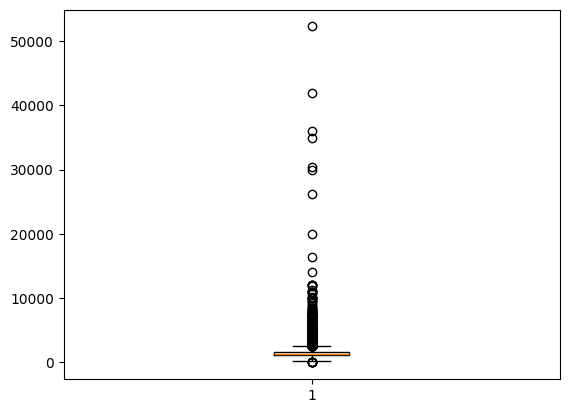

In [59]:
import matplotlib.pyplot as plt

plt.boxplot(df["total_sqft"])
plt.show()

In [60]:
Q1 = df["total_sqft"].quantile(0.25)
Q3 = df["total_sqft"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit, upper_limit)

233.0 2545.0


In [61]:
outliers = df[(df["total_sqft"] < lower_limit) | 
              (df["total_sqft"] > upper_limit)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 1172


Removing the outliers

In [62]:
print("Before:", df.shape)

Before: (13320, 10)


In [63]:
df = df[(df["total_sqft"] >= lower_limit) & 
        (df["total_sqft"] <= upper_limit)]

In [64]:
print("After:", df.shape)

After: (12148, 10)


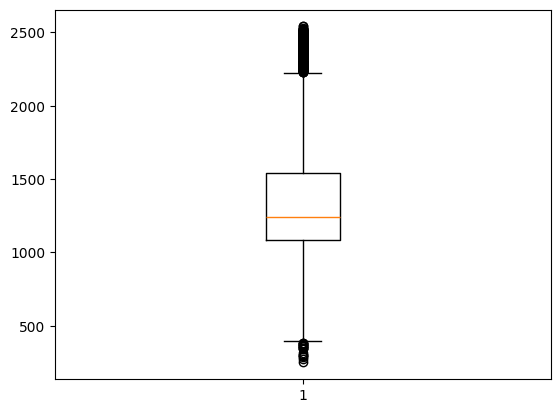

In [65]:
plt.boxplot(df["total_sqft"])
plt.show()

In [67]:
df = df.copy()

In [68]:
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,price_per_sqft
0,0,48.316667,2.0,1056.0,2.0,1.0,39.07,0,0,1,3699.810606
2,1,61.252527,3.0,1440.0,2.0,3.0,62.00,0,0,0,4305.555556
3,1,115.348261,3.0,1521.0,3.0,1.0,95.00,0,0,1,6245.890861
4,1,95.630303,2.0,1200.0,2.0,1.0,51.00,0,0,1,4250.000000
5,1,127.934667,2.0,1170.0,2.0,1.0,38.00,0,0,1,3247.863248


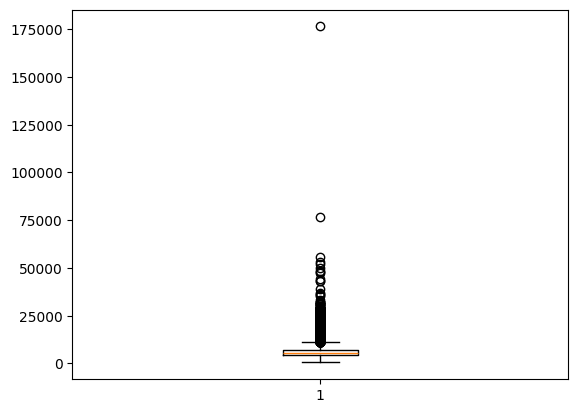

In [69]:
import matplotlib.pyplot as plt
plt.boxplot(df["price_per_sqft"])
plt.show()

In [70]:
Q1 = df["price_per_sqft"].quantile(0.25)
Q3 = df["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit,upper_limit)

df = df[(df["price_per_sqft"] >= lower_limit) & 
        (df["price_per_sqft"] <= upper_limit)]
df=df.copy()

81.98517930804155 11063.598419101982


In [71]:
df = df[df["bath"] <= df["size"] + 2]
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,price_per_sqft
0,0,48.316667,2.0,1056.0,2.0,1.0,39.07,0,0,1,3699.810606
2,1,61.252527,3.0,1440.0,2.0,3.0,62.00,0,0,0,4305.555556
3,1,115.348261,3.0,1521.0,3.0,1.0,95.00,0,0,1,6245.890861
4,1,95.630303,2.0,1200.0,2.0,1.0,51.00,0,0,1,4250.000000
5,1,127.934667,2.0,1170.0,2.0,1.0,38.00,0,0,1,3247.863248


In [72]:
df = df.drop("price_per_sqft", axis=1)
df.head()

,availability,location,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,48.316667,2.0,1056.0,2.0,1.0,39.07,0,0,1
2,1,61.252527,3.0,1440.0,2.0,3.0,62.00,0,0,0
3,1,115.348261,3.0,1521.0,3.0,1.0,95.00,0,0,1
4,1,95.630303,2.0,1200.0,2.0,1.0,51.00,0,0,1
5,1,127.934667,2.0,1170.0,2.0,1.0,38.00,0,0,1


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10984 entries, 0 to 13319
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   availability                    10984 non-null  int64  
 1   location                        10984 non-null  float64
 2   size                            10984 non-null  float64
 3   total_sqft                      10984 non-null  float64
 4   bath                            10984 non-null  float64
 5   balcony                         10984 non-null  float64
 6   price                           10984 non-null  float64
 7   area_type_Carpet  Area          10984 non-null  int64  
 8   area_type_Plot  Area            10984 non-null  int64  
 9   area_type_Super built-up  Area  10984 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 943.9 KB
